In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
pip install -q timm albumentations scikit-learn pandas matplotlib seaborn tqdm opencv-python-headless iterative-stratification

In [ ]:
import os
import random
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
from collections import OrderedDict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler  # [IMPROVED] Added WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, hamming_loss, classification_report,
    multilabel_confusion_matrix, roc_curve
)

# [FIX 1] MultilabelStratifiedKFold for proper multi-label stratified splitting
try:
    from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
    HAS_ITERSTRAT = True
    print("   ✅ iterative-stratification available")
except ImportError:
    HAS_ITERSTRAT = False
    print("   ⚠️ iterative-stratification not installed, will use fallback split")

warnings.filterwarnings("ignore")
print("✅ All imports successful.")

   ✅ iterative-stratification available
✅ All imports successful.


In [ ]:

def seed_everything(seed=42):
    """Set seeds for full reproducibility."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

🖥️  Device: cuda
   GPU: Tesla T4
   Memory: 15.6 GB


In [ ]:

class Config:
    """Central configuration for the entire pipeline."""
    # --- Data Paths (CONFIGURABLE — update for your environment) ---
    TRAIN_IMG_DIR = "/content/drive/MyDrive/odir/preprocessed_images"
    CSV_PATH = "/content/drive/MyDrive/odir/full_df.csv"

    # --- Model ---
    MODEL_NAME = "efficientnet_b3"
    IMG_SIZE = 224
    NUM_CLASSES = 8
    DISEASE_COLUMNS = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
    DISEASE_NAMES = {
        'N': 'Normal', 'D': 'Diabetes', 'G': 'Glaucoma',
        'C': 'Cataract', 'A': 'AMD', 'H': 'Hypertension',
        'M': 'Myopia', 'O': 'Other'
    }

    # --- Training ---
    BATCH_SIZE = 32          # Increase to 64 if GPU memory allows
    EPOCHS = 40
    LR = 3e-5                # [IMPROVED] Reduced from 1e-4 → 3e-5 for more stable fine-tuning
    WEIGHT_DECAY = 1e-5
    DROPOUT = 0.3
    GRAD_CLIP_NORM = 1.0
    PATIENCE = 8             # Early stopping patience

    # --- Two-Phase Training [IMPROVED] ---
    WARMUP_EPOCHS = 5        # Phase 1: freeze backbone, train head only
    WARMUP_LR = 1e-3         # Higher LR for head-only training (head is randomly initialized)

    # --- Scheduler ---
    SCHEDULER = "cosine"     # "cosine" or "plateau"
    T_MAX = 40               # For CosineAnnealingLR (will be adjusted for Phase 2)
    PLATEAU_FACTOR = 0.5
    PLATEAU_PATIENCE = 3

    # --- System ---
    SEED = 42
    NUM_WORKERS = 4
    PIN_MEMORY = True
    PERSISTENT_WORKERS = True
    USE_AMP = True           # Mixed precision training

    # --- CLAHE Preprocessing [IMPROVED] ---
    USE_CLAHE = True
    CLAHE_CLIP_LIMIT = 2.0
    CLAHE_TILE_SIZE = (8, 8)

    # --- Ensemble [IMPROVED] ---
    DENSENET_PRED_PATH = None  # Set to path of DenseNet121 predictions .npy if available
    ENSEMBLE_WEIGHT_EFFNET = 0.5
    ENSEMBLE_WEIGHT_DENSENET = 0.5

    # --- Outputs ---
    MODEL_PATH = "./efficientnet_odir_final.pth"
    REPORTS_DIR = "./reports_effnet"

cfg = Config()
os.makedirs(cfg.REPORTS_DIR, exist_ok=True)
print("⚙️  Configuration loaded.")
print(f"   Model: {cfg.MODEL_NAME} | Epochs: {cfg.EPOCHS} | LR: {cfg.LR}")
print(f"   Batch: {cfg.BATCH_SIZE} | IMG: {cfg.IMG_SIZE}x{cfg.IMG_SIZE}")
print(f"   [NEW] Warmup epochs: {cfg.WARMUP_EPOCHS} | CLAHE: {cfg.USE_CLAHE}")
print(f"   [NEW] Two-phase training: Phase1={cfg.WARMUP_EPOCHS}ep (head), Phase2={cfg.EPOCHS - cfg.WARMUP_EPOCHS}ep (full)")

⚙️  Configuration loaded.
   Model: efficientnet_b3 | Epochs: 40 | LR: 3e-05
   Batch: 32 | IMG: 224x224
   [NEW] Warmup epochs: 5 | CLAHE: True
   [NEW] Two-phase training: Phase1=5ep (head), Phase2=35ep (full)


📂 Loading dataset...
   Total rows: 6392
   Columns: ['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus', 'Right-Fundus', 'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O', 'filepath', 'labels', 'target', 'filename']
   ✅ No NaN values in label columns
   ✅ Labels validated: all values are 0 or 1
   Valid samples: 6392

📊 Label Distribution:
   D (    Diabetes):  2123 (33.2%)
   N (      Normal):  2101 (32.9%)
   O (       Other):  1588 (24.8%)
   C (    Cataract):   402 (6.3%)
   G (    Glaucoma):   397 (6.2%)
   A (         AMD):   319 (5.0%)
   M (      Myopia):   306 (4.8%)
   H (Hypertension):   203 (3.2%)

   Labels/sample — mean: 1.16, max: 3


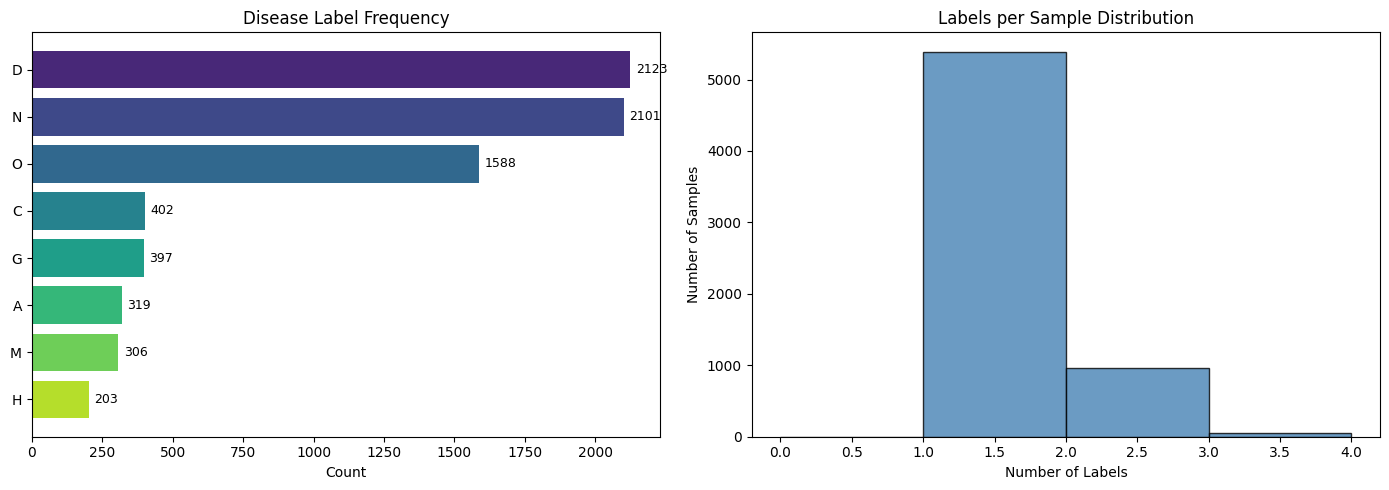

In [ ]:
print("📂 Loading dataset...")
df = pd.read_csv(cfg.CSV_PATH)
print(f"   Total rows: {len(df)}")
print(f"   Columns: {list(df.columns)}")

# ──────────────────────────────────────────────────────────────────────
# [FIX 2] Handle NaN values in dataset BEFORE any processing
# NaN labels cause BCEWithLogitsLoss to return NaN, which cascades
# into NaN validation loss and broken AUC computation.
# ──────────────────────────────────────────────────────────────────────
nan_counts = df[cfg.DISEASE_COLUMNS].isnull().sum()
total_nans = nan_counts.sum()
if total_nans > 0:
    print(f"\n   ⚠️ Found {total_nans} NaN values in label columns:")
    for col, cnt in nan_counts.items():
        if cnt > 0:
            print(f"      {col}: {cnt} NaN values")
    # Replace NaN with 0 (absence of disease is the safe default)
    df[cfg.DISEASE_COLUMNS] = df[cfg.DISEASE_COLUMNS].fillna(0)
    print(f"   ✅ All NaN labels replaced with 0")
else:
    print("   ✅ No NaN values in label columns")

# [FIX 2b] Ensure labels are strictly 0 or 1 (no floats, no negatives)
for col in cfg.DISEASE_COLUMNS:
    df[col] = df[col].astype(float).clip(0, 1).round().astype(int)
print("   ✅ Labels validated: all values are 0 or 1")

# Build image paths and filter missing
df['image_path'] = df['filename'].apply(lambda fn: os.path.join(cfg.TRAIN_IMG_DIR, fn))
df['exists'] = df['image_path'].apply(os.path.isfile)
missing = (~df['exists']).sum()
if missing > 0:
    print(f"   ⚠️ {missing} images not found — skipping.")
df = df[df['exists']].reset_index(drop=True)
print(f"   Valid samples: {len(df)}")

# Label distribution
print("\n📊 Label Distribution:")
label_counts = df[cfg.DISEASE_COLUMNS].sum().sort_values(ascending=False)
for col, cnt in label_counts.items():
    pct = cnt / len(df) * 100
    name = cfg.DISEASE_NAMES.get(col, col)
    print(f"   {col} ({name:>12s}): {int(cnt):>5d} ({pct:.1f}%)")

# Multi-label stats
labels_per_sample = df[cfg.DISEASE_COLUMNS].sum(axis=1)
print(f"\n   Labels/sample — mean: {labels_per_sample.mean():.2f}, max: {labels_per_sample.max():.0f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = sns.color_palette("viridis", n_colors=cfg.NUM_CLASSES)
axes[0].barh(label_counts.index, label_counts.values, color=colors)
axes[0].set_xlabel("Count")
axes[0].set_title("Disease Label Frequency")
axes[0].invert_yaxis()
for i, v in enumerate(label_counts.values):
    axes[0].text(v + 20, i, str(int(v)), va='center', fontsize=9)

axes[1].hist(labels_per_sample, bins=range(0, int(labels_per_sample.max())+2),
             edgecolor='black', color='steelblue', alpha=0.8)
axes[1].set_xlabel("Number of Labels")
axes[1].set_ylabel("Number of Samples")
axes[1].set_title("Labels per Sample Distribution")
plt.tight_layout()
plt.savefig(os.path.join(cfg.REPORTS_DIR, "label_distribution.png"), dpi=150)
plt.show()

In [ ]:

print("⚖️  Computing pos_weight for BCEWithLogitsLoss...")
label_array = df[cfg.DISEASE_COLUMNS].values.astype(np.float32)
pos_counts = label_array.sum(axis=0)
neg_counts = len(label_array) - pos_counts
pos_weight = neg_counts / (pos_counts + 1e-6)

# Clamp extreme weights
pos_weight = np.clip(pos_weight, 1.0, 20.0)
pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float32).to(DEVICE)

print("\n   Class  | Positive | Negative | pos_weight")
print("   " + "-" * 48)
for i, col in enumerate(cfg.DISEASE_COLUMNS):
    print(f"   {col:>5s}  | {int(pos_counts[i]):>8d} | {int(neg_counts[i]):>8d} | {pos_weight[i]:>10.2f}")

⚖️  Computing pos_weight for BCEWithLogitsLoss...

   Class  | Positive | Negative | pos_weight
   ------------------------------------------------
       N  |     2101 |     4291 |       2.04
       D  |     2123 |     4269 |       2.01
       G  |      397 |     5995 |      15.10
       C  |      402 |     5990 |      14.90
       A  |      319 |     6073 |      19.04
       H  |      203 |     6189 |      20.00
       M  |      306 |     6086 |      19.89
       O  |     1588 |     4804 |       3.03


In [ ]:

# ──────────────────────────────────────────────────────────────────────
# CLAHE (Contrast Limited Adaptive Histogram Equalization) enhances
# local contrast in retinal fundus images, making vessel structures,
# microaneurysms, and lesion boundaries more visible to the CNN.
# Applied on the L channel of LAB color space to preserve color info.
# ──────────────────────────────────────────────────────────────────────

class CLAHEPreprocess(A.ImageOnlyTransform):
    """
    Custom Albumentations transform that applies CLAHE on the luminance
    channel of the LAB color space. This is standard practice for
    retinal image preprocessing in medical imaging.

    Why LAB instead of just green channel?
    - LAB separates luminance from chrominance, so CLAHE enhances
      contrast without distorting color information
    - The green channel approach loses 2/3 of color information
    """
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8), always_apply=False, p=1.0):
        super().__init__(always_apply, p)
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size

    def apply(self, img, **params):
        # Convert RGB to LAB color space
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        # Split into L, A, B channels
        l_channel, a_channel, b_channel = cv2.split(lab)
        # Apply CLAHE to the luminance channel only
        clahe = cv2.createCLAHE(
            clipLimit=self.clip_limit,
            tileGridSize=self.tile_grid_size
        )
        l_enhanced = clahe.apply(l_channel)
        # Merge back and convert to RGB
        lab_enhanced = cv2.merge([l_enhanced, a_channel, b_channel])
        result = cv2.cvtColor(lab_enhanced, cv2.COLOR_LAB2RGB)
        return result

    def get_transform_init_args_names(self):
        return ("clip_limit", "tile_grid_size")

if cfg.USE_CLAHE:
    print("🔬 CLAHE preprocessing enabled (LAB luminance channel)")
    print(f"   clipLimit={cfg.CLAHE_CLIP_LIMIT}, tileGridSize={cfg.CLAHE_TILE_SIZE}")
else:
    print("ℹ️  CLAHE preprocessing disabled")

🔬 CLAHE preprocessing enabled (LAB luminance channel)
   clipLimit=2.0, tileGridSize=(8, 8)


In [ ]:

class ODIRDataset(Dataset):
    """ODIR-5K multi-label retinal disease dataset."""

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels.astype(np.float32)
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = cv2.imread(img_path)
        if image is None:
            # Fallback: black image
            image = np.zeros((cfg.IMG_SIZE, cfg.IMG_SIZE, 3), dtype=np.uint8)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return image, label

print("✅ ODIRDataset class defined.")

✅ ODIRDataset class defined.


In [ ]:

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# [IMPROVED] Build augmentation pipeline with optional CLAHE as the first step
# CLAHE is applied BEFORE normalization and augmentations so that:
# 1. It operates on the original pixel range (0-255)
# 2. Subsequent augmentations work on the enhanced image
train_transform_list = []

# Step 1: CLAHE preprocessing (retina-specific enhancement)
if cfg.USE_CLAHE:
    train_transform_list.append(
        CLAHEPreprocess(
            clip_limit=cfg.CLAHE_CLIP_LIMIT,
            tile_grid_size=cfg.CLAHE_TILE_SIZE,
            p=1.0  # Always apply — this is preprocessing, not augmentation
        )
    )

# Step 2: Standard augmentations
train_transform_list.extend([
    A.Resize(cfg.IMG_SIZE, cfg.IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=15, p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15,
                       border_mode=cv2.BORDER_CONSTANT, p=0.4),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.CoarseDropout(max_holes=4, max_height=20, max_width=20, p=0.2),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

train_transforms = A.Compose(train_transform_list)

# Validation transforms also get CLAHE (must match training preprocessing)
val_transform_list = []
if cfg.USE_CLAHE:
    val_transform_list.append(
        CLAHEPreprocess(
            clip_limit=cfg.CLAHE_CLIP_LIMIT,
            tile_grid_size=cfg.CLAHE_TILE_SIZE,
            p=1.0
        )
    )
val_transform_list.extend([
    A.Resize(cfg.IMG_SIZE, cfg.IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

val_transforms = A.Compose(val_transform_list)

print("✅ Augmentation pipelines defined.")
print(f"   Train augmentations: {len(train_transforms.transforms)} transforms" +
      (" (includes CLAHE)" if cfg.USE_CLAHE else ""))
print(f"   Val augmentations:   {len(val_transforms.transforms)} transforms" +
      (" (includes CLAHE)" if cfg.USE_CLAHE else ""))

✅ Augmentation pipelines defined.
   Train augmentations: 11 transforms (includes CLAHE)
   Val augmentations:   4 transforms (includes CLAHE)


In [ ]:
# %% Cell 9 — DataLoaders [FIX 1: MultilabelStratifiedKFold + WeightedRandomSampler]

# ──────────────────────────────────────────────────────────────────────
# [FIX 1] Proper Multi-Label Stratified Split using iterative-stratification
# The previous approach (stratify on rarest label) is an approximation that
# can fail when rare classes end up entirely in one split, causing:
#   - AUC computation to fail (only 1 class present → ValueError)
#   - Validation loss to become NaN (extreme pos_weight imbalance)
# MultilabelStratifiedKFold uses iterative stratification to ensure
# EVERY class has both positive and negative samples in BOTH splits.
# ──────────────────────────────────────────────────────────────────────

image_paths = df['image_path'].values
labels = df[cfg.DISEASE_COLUMNS].values.astype(np.float32)  # [FIX 6] Ensure float32

if HAS_ITERSTRAT:
    # Use MultilabelStratifiedKFold with n_splits=5 (80/20 split using 1 fold)
    mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=cfg.SEED)
    train_idx, val_idx = next(iter(mskf.split(image_paths, labels)))
    X_train, X_val = image_paths[train_idx], image_paths[val_idx]
    y_train, y_val = labels[train_idx], labels[val_idx]
    print("📦 Split — MultilabelStratifiedKFold split successful (iterative stratification)")
else:
    # Fallback: approximate stratification on rarest label
    label_freq = labels.sum(axis=0)
    stratify_keys = []
    for row in labels:
        positive_indices = np.where(row == 1)[0]
        if len(positive_indices) == 0:
            stratify_keys.append(cfg.NUM_CLASSES)
        else:
            rarest_idx = positive_indices[np.argmin(label_freq[positive_indices])]
            stratify_keys.append(rarest_idx)
    stratify_keys = np.array(stratify_keys)
    try:
        X_train, X_val, y_train, y_val = train_test_split(
            image_paths, labels, test_size=0.2,
            random_state=cfg.SEED, shuffle=True,
            stratify=stratify_keys
        )
        print("📦 Split — Approximate stratified split successful")
    except ValueError as e:
        print(f"⚠️  Stratified split failed ({e}), falling back to random split")
        X_train, X_val, y_train, y_val = train_test_split(
            image_paths, labels, test_size=0.2,
            random_state=cfg.SEED, shuffle=True
        )

print(f"   Train: {len(X_train)}, Val: {len(X_val)}")

# [FIX 5] Debug validation data — verify no class is completely missing
print("\n📊 Label Distribution After Split:")
print(f"   {'Class':>6s} | {'Train':>6s} ({'%':>5s}) | {'Val':>5s} ({'%':>5s}) | {'Ratio':>6s}")
print("   " + "-" * 55)
val_issues = []
for i, col in enumerate(cfg.DISEASE_COLUMNS):
    train_cnt = y_train[:, i].sum()
    val_cnt = y_val[:, i].sum()
    train_pct = train_cnt / len(y_train) * 100
    val_pct = val_cnt / len(y_val) * 100
    ratio = train_pct / (val_pct + 1e-6)
    # [FIX 5] Check if validation has BOTH positive and negative samples
    val_unique = len(set(y_val[:, i].astype(int)))
    if val_unique < 2:
        balance = "🚨 MISSING"
        val_issues.append(col)
    elif 0.85 <= ratio <= 1.15:
        balance = "✅"
    else:
        balance = "⚠️"
    print(f"   {col:>6s} | {int(train_cnt):>6d} ({train_pct:>5.1f}%) | {int(val_cnt):>5d} ({val_pct:>5.1f}%) | {ratio:>6.2f} {balance}")

if val_issues:
    print(f"\n   🚨 WARNING: Classes with missing pos/neg in validation: {val_issues}")
    print(f"   These classes will be skipped in AUC computation.")
else:
    print(f"\n   ✅ All classes have both positive and negative samples in validation")

# [FIX 5] Print debug summary of validation label shapes and sums
print(f"\n🔍 Debug — Validation label stats:")
print(f"   Shape: {y_val.shape}, dtype: {y_val.dtype}")
print(f"   Per-class positive counts: {y_val.sum(axis=0).astype(int)}")
print(f"   Total labels: {y_val.sum():.0f}, NaN count: {np.isnan(y_val).sum()}")

train_dataset = ODIRDataset(X_train, y_train, transform=train_transforms)
val_dataset = ODIRDataset(X_val, y_val, transform=val_transforms)

# ──────────────────────────────────────────────────────────────────────
# [IMPROVED] WeightedRandomSampler for Multi-Label Class Imbalance
# ──────────────────────────────────────────────────────────────────────
# For multi-label data, we compute per-sample weights based on all
# positive labels: samples with rare diseases get higher sampling
# probability. This ensures the model sees rare conditions more often.

print("\n⚖️  Computing WeightedRandomSampler weights...")

# Step 1: Compute class frequencies in training set
train_class_freq = y_train.sum(axis=0)  # [NUM_CLASSES]
train_class_weight = 1.0 / (train_class_freq + 1e-6)  # Inverse frequency

# Step 2: For each sample, compute weight as the max weight across its positive labels
# Using max ensures that even if a sample has one common + one rare label,
# it gets upsampled due to the rare label
sample_weights = np.zeros(len(y_train))
for i in range(len(y_train)):
    positive_mask = y_train[i] == 1
    if positive_mask.any():
        # Weight = max of inverse frequencies across all positive labels
        sample_weights[i] = train_class_weight[positive_mask].max()
    else:
        sample_weights[i] = 1.0  # Default weight for samples with no label

# Normalize weights to prevent extreme values
sample_weights = sample_weights / sample_weights.sum() * len(sample_weights)

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(train_dataset),
    replacement=True  # Required for weighted sampling
)

print(f"   Sample weight range: [{sample_weights.min():.4f}, {sample_weights.max():.4f}]")
print(f"   Effective upsampling ratio (max/min): {sample_weights.max()/sample_weights.min():.1f}x")

worker_kwargs = dict(
    num_workers=cfg.NUM_WORKERS,
    pin_memory=cfg.PIN_MEMORY,
)
# Add persistent_workers only if num_workers > 0
if cfg.NUM_WORKERS > 0:
    worker_kwargs['persistent_workers'] = cfg.PERSISTENT_WORKERS

# [IMPROVED] Use WeightedRandomSampler instead of shuffle=True
# Note: sampler and shuffle are mutually exclusive in DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.BATCH_SIZE,
    sampler=sampler,        # [IMPROVED] Replaces shuffle=True
    drop_last=True,
    **worker_kwargs
)
val_loader = DataLoader(val_dataset, batch_size=cfg.BATCH_SIZE, shuffle=False, drop_last=False, **worker_kwargs)

print(f"\n   Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

# Quick sanity check
imgs, lbls = next(iter(train_loader))
print(f"   Batch shape: {imgs.shape}, Labels shape: {lbls.shape}")

📦 Split — MultilabelStratifiedKFold split successful (iterative stratification)
   Train: 5104, Val: 1288

📊 Label Distribution After Split:
    Class |  Train (    %) |   Val (    %) |  Ratio
   -------------------------------------------------------
        N |   1681 ( 32.9%) |   420 ( 32.6%) |   1.01 ✅
        D |   1699 ( 33.3%) |   424 ( 32.9%) |   1.01 ✅
        G |    318 (  6.2%) |    79 (  6.1%) |   1.02 ✅
        C |    321 (  6.3%) |    81 (  6.3%) |   1.00 ✅
        A |    255 (  5.0%) |    64 (  5.0%) |   1.01 ✅
        H |    162 (  3.2%) |    41 (  3.2%) |   1.00 ✅
        M |    245 (  4.8%) |    61 (  4.7%) |   1.01 ✅
        O |   1271 ( 24.9%) |   317 ( 24.6%) |   1.01 ✅

   ✅ All classes have both positive and negative samples in validation

🔍 Debug — Validation label stats:
   Shape: (1288, 8), dtype: float32
   Per-class positive counts: [420 424  79  81  64  41  61 317]
   Total labels: 1487, NaN count: 0

⚖️  Computing WeightedRandomSampler weights...
   Sample

In [ ]:

class EfficientNetB3Classifier(nn.Module):
    """EfficientNet-B3 backbone with custom multi-label classification head.

    [IMPROVED] Added methods for two-phase training:
    - freeze_backbone(): Freeze all backbone parameters (Phase 1)
    - unfreeze_backbone(): Unfreeze all backbone parameters (Phase 2)
    """

    def __init__(self, num_classes=8, dropout=0.3, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            'efficientnet_b3',
            pretrained=pretrained,
            num_classes=0,  # Remove classifier head — returns features
            drop_rate=0.0,
        )
        in_features = self.backbone.num_features  # 1536 for EfficientNet-B3
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes),
        )
        print(f"   Backbone features: {in_features}")

    def forward(self, x):
        features = self.backbone(x)     # [B, 1536]
        logits = self.head(features)    # [B, num_classes]
        return logits

    def freeze_backbone(self):
        """[IMPROVED] Freeze all backbone parameters for Phase 1 (head-only training).
        This prevents catastrophic forgetting of pretrained ImageNet features
        while the randomly-initialized head learns the ODIR-5K label space."""
        for param in self.backbone.parameters():
            param.requires_grad = False
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"   🧊 Backbone FROZEN — trainable params: {trainable:,}")

    def unfreeze_backbone(self):
        """[IMPROVED] Unfreeze all parameters for Phase 2 (full fine-tuning).
        Now that the head has learned reasonable predictions, the entire
        network can be fine-tuned end-to-end with a lower learning rate."""
        for param in self.backbone.parameters():
            param.requires_grad = True
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"   🔥 Backbone UNFROZEN — trainable params: {trainable:,}")

model = EfficientNetB3Classifier(
    num_classes=cfg.NUM_CLASSES,
    dropout=cfg.DROPOUT,
    pretrained=True,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n🧠 EfficientNet-B3 Classifier")
print(f"   Total params:     {total_params:>12,}")
print(f"   Trainable params: {trainable_params:>12,}")

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

   Backbone features: 1536

🧠 EfficientNet-B3 Classifier
   Total params:       10,708,528
   Trainable params:   10,708,528


In [ ]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

# ──────────────────────────────────────────────────────────────────────
# [IMPROVED] Two-Phase Training Setup
# Phase 1 (Warmup): Freeze backbone, only train classification head
#   - Uses higher LR (1e-3) since head weights are random
#   - Epochs: WARMUP_EPOCHS (default 5)
# Phase 2 (Fine-tuning): Unfreeze everything, train end-to-end
#   - Uses lower LR (3e-5) to avoid disrupting pretrained features
#   - Remaining epochs with CosineAnnealingLR
# ──────────────────────────────────────────────────────────────────────

# Phase 1: Freeze backbone and set up head-only optimizer
model.freeze_backbone()

# Phase 1 optimizer: higher LR for randomly-initialized head
optimizer_phase1 = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),  # Only head params
    lr=cfg.WARMUP_LR,
    weight_decay=cfg.WEIGHT_DECAY,
)
scheduler_phase1 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_phase1, T_max=cfg.WARMUP_EPOCHS, eta_min=1e-5
)

# Phase 2 optimizer: lower LR for full model fine-tuning
# (will be initialized when Phase 2 starts)
phase2_epochs = cfg.EPOCHS - cfg.WARMUP_EPOCHS

scaler = GradScaler(enabled=cfg.USE_AMP)

print("\n✅ Loss: BCEWithLogitsLoss (pos_weight)")
print(f"   Phase 1 — Head-only: AdamW (lr={cfg.WARMUP_LR}, epochs={cfg.WARMUP_EPOCHS})")
print(f"   Phase 2 — Full model: AdamW (lr={cfg.LR}, epochs={phase2_epochs})")
print(f"   AMP: {cfg.USE_AMP} | Grad Clip: {cfg.GRAD_CLIP_NORM}")

   🧊 Backbone FROZEN — trainable params: 12,296

✅ Loss: BCEWithLogitsLoss (pos_weight)
   Phase 1 — Head-only: AdamW (lr=0.001, epochs=5)
   Phase 2 — Full model: AdamW (lr=3e-05, epochs=35)
   AMP: True | Grad Clip: 1.0


In [ ]:
# %% Cell 12 — Training Loop + safe_auc helper

# ──────────────────────────────────────────────────────────────────────
# [FIX 4] Robust ROC-AUC computation that handles degenerate classes
# Standard roc_auc_score(average='macro') FAILS with ValueError when
# ANY class has only one label value (all 0 or all 1) in the batch.
# This is common with rare diseases in multi-label classification.
# Our safe_auc computes AUC per-class, skips degenerate classes,
# and returns the mean of valid AUCs.
# ──────────────────────────────────────────────────────────────────────
def safe_auc(y_true, y_pred):
    """Compute macro ROC-AUC safely, skipping classes with only one label value.

    Args:
        y_true: Ground truth labels, shape [N, C]
        y_pred: Predicted probabilities, shape [N, C]

    Returns:
        float: Mean AUC across valid classes, or 0.5 if no valid class exists
    """
    aucs = []
    for i in range(y_true.shape[1]):
        # Skip classes where all samples have the same label (can't compute AUC)
        unique_labels = set(y_true[:, i].astype(int))
        if len(unique_labels) > 1:
            try:
                auc = roc_auc_score(y_true[:, i], y_pred[:, i])
                # [FIX 3] Also skip if AUC is NaN (shouldn't happen but be safe)
                if not np.isnan(auc):
                    aucs.append(auc)
            except (ValueError, IndexError):
                continue
    return np.mean(aucs) if len(aucs) > 0 else 0.5

def safe_per_class_auc(y_true, y_pred, class_names):
    """Compute per-class AUC safely, returning 0.5 for degenerate classes."""
    aucs = np.full(y_true.shape[1], 0.5)  # Default to 0.5 (random)
    for i in range(y_true.shape[1]):
        unique_labels = set(y_true[:, i].astype(int))
        if len(unique_labels) > 1:
            try:
                aucs[i] = roc_auc_score(y_true[:, i], y_pred[:, i])
                if np.isnan(aucs[i]):
                    aucs[i] = 0.5
            except (ValueError, IndexError):
                aucs[i] = 0.5
    return aucs

print("✅ safe_auc() and safe_per_class_auc() defined")

def train_one_epoch(model, loader, criterion, optimizer, scaler, device, grad_clip=1.0):
    """Train for one epoch with AMP and gradient clipping."""
    model.train()
    running_loss = 0.0
    valid_batches = 0  # [FIX 3] Track valid (non-NaN) batches
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc="  Train", leave=False)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).float()  # [FIX 6] Ensure float32

        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=cfg.USE_AMP):
            logits = model(images)
            loss = criterion(logits, labels)

        # [FIX 3] Handle NaN loss — skip batch if loss is NaN
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"      ⚠️ Train: NaN/Inf loss detected, skipping batch")
            optimizer.zero_grad(set_to_none=True)
            continue

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        valid_batches += images.size(0)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_preds.append(probs)
        all_labels.append(labels.cpu().numpy())

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    # [FIX 3] Safe division — avoid NaN if all batches were skipped
    epoch_loss = running_loss / max(valid_batches, 1)
    all_preds = np.concatenate(all_preds) if all_preds else np.zeros((1, cfg.NUM_CLASSES))
    all_labels = np.concatenate(all_labels) if all_labels else np.zeros((1, cfg.NUM_CLASSES))

    # [FIX 4] Use safe_auc instead of raw roc_auc_score
    epoch_auc = safe_auc(all_labels, all_preds)

    return epoch_loss, epoch_auc

✅ safe_auc() and safe_per_class_auc() defined


In [ ]:
# %% Cell 13 — Validation Loop + Main Training [FIXED: NaN-safe, robust AUC]

# ──────────────────────────────────────────────────────────────────────
# [FIX 3, 4, 6, 7] Complete validation pipeline fixes:
#   - FIX 3: NaN-safe loss computation (nan_to_num + skip invalid batches)
#   - FIX 4: safe_auc() instead of raw roc_auc_score
#   - FIX 6: Explicit float32 tensor casting for labels
#   - FIX 7: model.eval() + @torch.no_grad() explicitly verified
# ──────────────────────────────────────────────────────────────────────
@torch.no_grad()  # [FIX 7] Ensure no gradient computation during validation
def validate(model, loader, criterion, device):
    """Validate and collect predictions for metric computation.

    Fixed version with:
    - NaN-safe loss accumulation
    - Robust AUC computation (skips degenerate classes)
    - Explicit float32 tensor types
    - NaN detection warnings for debugging
    """
    model.eval()  # [FIX 7] Ensure evaluation mode (disables dropout, batchnorm uses running stats)
    running_loss = 0.0
    valid_samples = 0  # [FIX 3] Count only valid (non-NaN) samples
    nan_batch_count = 0  # [FIX 3] Track NaN occurrences for debugging
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc="  Valid", leave=False)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).float()  # [FIX 6] Ensure float32

        with autocast(enabled=cfg.USE_AMP):
            logits = model(images)
            loss = criterion(logits, labels)

        # [FIX 3] Check for NaN in model outputs (indicates upstream data issues)
        if torch.isnan(logits).any():
            nan_batch_count += 1
            if nan_batch_count <= 3:  # Only print first 3 warnings to avoid spam
                print(f"      ⚠️ Valid: NaN detected in model outputs (batch {nan_batch_count})")
            continue  # Skip this batch entirely

        # [FIX 3] Replace NaN/Inf loss with 0 to prevent cascade
        loss_val = loss.item()
        if np.isnan(loss_val) or np.isinf(loss_val):
            nan_batch_count += 1
            if nan_batch_count <= 3:
                print(f"      ⚠️ Valid: NaN/Inf loss detected (batch {nan_batch_count})")
            loss_val = 0.0  # Don't count this batch in the loss
        else:
            running_loss += loss_val * images.size(0)
            valid_samples += images.size(0)

        # [FIX 6] Predictions must be sigmoid outputs (NOT logits)
        probs = torch.sigmoid(logits).cpu().numpy().astype(np.float32)
        # Clamp to [0, 1] range (safety against numerical issues from AMP)
        probs = np.clip(probs, 0.0, 1.0)
        all_preds.append(probs)
        all_labels.append(labels.cpu().numpy().astype(np.float32))

    # [FIX 3] Safe epoch loss computation — avoid division by zero
    if valid_samples > 0:
        epoch_loss = running_loss / valid_samples
    else:
        print("   🚨 WARNING: No valid validation batches! All produced NaN.")
        epoch_loss = float('inf')  # Signal that something is very wrong

    if nan_batch_count > 0:
        print(f"   ⚠️ Total NaN batches in validation: {nan_batch_count}")

    all_preds = np.concatenate(all_preds) if all_preds else np.zeros((1, cfg.NUM_CLASSES), dtype=np.float32)
    all_labels = np.concatenate(all_labels) if all_labels else np.zeros((1, cfg.NUM_CLASSES), dtype=np.float32)

    # [FIX 4] Use safe_auc — handles classes with only one label value
    epoch_auc = safe_auc(all_labels, all_preds)

    f1_macro = f1_score(
        all_labels.astype(int),  # [FIX 6] Ensure integer labels for F1
        (all_preds > 0.5).astype(int),
        average='macro',
        zero_division=0
    )

    return epoch_loss, epoch_auc, f1_macro, all_preds, all_labels

# --- Main Training Loop [IMPROVED with Two-Phase Training] ---
print("=" * 70)
print(f"🚀 Starting Two-Phase Training on {DEVICE}")
print(f"   Phase 1: {cfg.WARMUP_EPOCHS} epochs (head only, LR={cfg.WARMUP_LR})")
print(f"   Phase 2: {phase2_epochs} epochs (full model, LR={cfg.LR})")
print("=" * 70)

history = {'train_loss': [], 'val_loss': [], 'train_auc': [], 'val_auc': [], 'val_f1': [], 'lr': [], 'phase': []}
best_auc = 0.0
patience_counter = 0
best_preds, best_labels = None, None
global_epoch = 0

# ══════════════════════════════════════════════════════════════════════
# PHASE 1: Warmup — Train classification head only (backbone frozen)
# ══════════════════════════════════════════════════════════════════════
print(f"\n{'━'*70}")
print(f"🧊 PHASE 1 — HEAD WARMUP (backbone frozen, {cfg.WARMUP_EPOCHS} epochs)")
print(f"{'━'*70}")

for epoch in range(1, cfg.WARMUP_EPOCHS + 1):
    global_epoch += 1
    current_lr = optimizer_phase1.param_groups[0]['lr']
    print(f"\n{'─'*60}")
    print(f"Phase 1 | Epoch {epoch}/{cfg.WARMUP_EPOCHS} (global {global_epoch})  |  LR: {current_lr:.2e}")

    train_loss, train_auc = train_one_epoch(
        model, train_loader, criterion, optimizer_phase1, scaler, DEVICE, cfg.GRAD_CLIP_NORM
    )
    val_loss, val_auc, val_f1, val_preds, val_labels = validate(
        model, val_loader, criterion, DEVICE
    )

    scheduler_phase1.step()

    # Logging
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_auc'].append(train_auc)
    history['val_auc'].append(val_auc)
    history['val_f1'].append(val_f1)
    history['lr'].append(current_lr)
    history['phase'].append(1)

    print(f"  Train — Loss: {train_loss:.4f} | AUC: {train_auc:.4f}")
    print(f"  Valid — Loss: {val_loss:.4f} | AUC: {val_auc:.4f} | F1: {val_f1:.4f}")

    # Save best model even in Phase 1
    if val_auc > best_auc:
        best_auc = val_auc
        best_preds = val_preds.copy()
        best_labels = val_labels.copy()
        torch.save(model.state_dict(), cfg.MODEL_PATH)
        print(f"  💾 Best model saved (AUC={best_auc:.4f})")

print(f"\n✅ Phase 1 complete. Best AUC so far: {best_auc:.4f}")

# ══════════════════════════════════════════════════════════════════════
# PHASE 2: Fine-tuning — Full model training (backbone unfrozen)
# ══════════════════════════════════════════════════════════════════════
print(f"\n{'━'*70}")
print(f"🔥 PHASE 2 — FULL FINE-TUNING (backbone unfrozen, {phase2_epochs} epochs)")
print(f"{'━'*70}")

# Unfreeze and create new optimizer with lower LR for the full model
model.unfreeze_backbone()

optimizer = optim.AdamW(
    model.parameters(),
    lr=cfg.LR,
    weight_decay=cfg.WEIGHT_DECAY,
)

if cfg.SCHEDULER == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=phase2_epochs, eta_min=1e-7
    )
else:
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=cfg.PLATEAU_FACTOR,
        patience=cfg.PLATEAU_PATIENCE, verbose=True,
    )

# Reset patience counter for Phase 2
patience_counter = 0

for epoch in range(1, phase2_epochs + 1):
    global_epoch += 1
    current_lr = optimizer.param_groups[0]['lr']
    print(f"\n{'─'*60}")
    print(f"Phase 2 | Epoch {epoch}/{phase2_epochs} (global {global_epoch})  |  LR: {current_lr:.2e}")

    train_loss, train_auc = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler, DEVICE, cfg.GRAD_CLIP_NORM
    )
    val_loss, val_auc, val_f1, val_preds, val_labels = validate(
        model, val_loader, criterion, DEVICE
    )

    # Scheduler step
    if cfg.SCHEDULER == "cosine":
        scheduler.step()
    else:
        scheduler.step(val_auc)

    # Logging
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_auc'].append(train_auc)
    history['val_auc'].append(val_auc)
    history['val_f1'].append(val_f1)
    history['lr'].append(current_lr)
    history['phase'].append(2)

    print(f"  Train — Loss: {train_loss:.4f} | AUC: {train_auc:.4f}")
    print(f"  Valid — Loss: {val_loss:.4f} | AUC: {val_auc:.4f} | F1: {val_f1:.4f}")

    # Early stopping on val AUC
    if val_auc > best_auc:
        best_auc = val_auc
        patience_counter = 0
        best_preds = val_preds.copy()
        best_labels = val_labels.copy()
        torch.save(model.state_dict(), cfg.MODEL_PATH)
        print(f"  💾 Best model saved (AUC={best_auc:.4f})")
    else:
        patience_counter += 1
        print(f"  ⏳ No improvement ({patience_counter}/{cfg.PATIENCE})")
        if patience_counter >= cfg.PATIENCE:
            print(f"\n🛑 Early stopping at epoch {global_epoch} (best AUC: {best_auc:.4f})")
            break

print(f"\n✅ Training complete. Best Validation AUC: {best_auc:.4f}")

🚀 Starting Two-Phase Training on cuda
   Phase 1: 5 epochs (head only, LR=0.001)
   Phase 2: 35 epochs (full model, LR=3e-05)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🧊 PHASE 1 — HEAD WARMUP (backbone frozen, 5 epochs)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

────────────────────────────────────────────────────────────
Phase 1 | Epoch 1/5 (global 1)  |  LR: 1.00e-03


  Train:   0%|          | 0/159 [00:16<?, ?it/s]

  Valid:   0%|          | 0/41 [00:00<?, ?it/s]

  Train — Loss: 1.2926 | AUC: 0.7021
  Valid — Loss: 1.0626 | AUC: 0.7351 | F1: 0.2198
  💾 Best model saved (AUC=0.7351)

────────────────────────────────────────────────────────────
Phase 1 | Epoch 2/5 (global 2)  |  LR: 9.05e-04


  Train:   0%|          | 0/159 [00:00<?, ?it/s]

...

  Valid:   0%|          | 0/41 [00:00<?, ?it/s]

  Train — Loss: 0.3093 | AUC: 0.9524
  Valid — Loss: 0.9186 | AUC: 0.8290 | F1: 0.5097
  ⏳ No improvement (2/8)

────────────────────────────────────────────────────────────
Phase 2 | Epoch 35/35 (global 40)  |  LR: 1.60e-07


  Train:   0%|          | 0/159 [00:00<?, ?it/s]

  Valid:   0%|          | 0/41 [00:00<?, ?it/s]

  Train — Loss: 0.3031 | AUC: 0.9546
  Valid — Loss: 0.9124 | AUC: 0.8298 | F1: 0.5093
  💾 Best model saved (AUC=0.8298)

✅ Training complete. Best Validation AUC: 0.8298


In [ ]:
# %% Cell 14 — Threshold Optimization [IMPROVED with expanded search range]
print("🎯 Per-Class Threshold Optimization (maximizing F1)...")

# Reload best model predictions
model.load_state_dict(torch.load(cfg.MODEL_PATH, map_location=DEVICE))
_, _, _, val_preds_final, val_labels_final = validate(model, val_loader, criterion, DEVICE)

optimal_thresholds = {}
print(f"\n   {'Class':>6s} | {'OptThresh':>9s} | {'F1@0.5':>7s} | {'F1@Opt':>7s}")
print("   " + "-" * 45)

for i, col in enumerate(cfg.DISEASE_COLUMNS):
    best_f1 = 0.0
    best_thresh = 0.5

    # [IMPROVED] Expanded search range: 0.05 → 0.95 (was 0.1 → 0.9)
    # Wider range catches rare classes that need very low thresholds
    # and dominant classes that benefit from higher thresholds
    for thresh in np.arange(0.05, 0.95, 0.01):
        preds_binary = (val_preds_final[:, i] >= thresh).astype(int)
        f1 = f1_score(val_labels_final[:, i], preds_binary, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh

    # F1 at default 0.5
    f1_default = f1_score(
        val_labels_final[:, i],
        (val_preds_final[:, i] >= 0.5).astype(int),
        zero_division=0,
    )
    optimal_thresholds[col] = round(float(best_thresh), 2)
    improvement = "✅" if best_f1 > f1_default else "  "
    print(f"   {col:>6s} | {best_thresh:>9.2f} | {f1_default:>7.4f} | {best_f1:>7.4f} {improvement}")

# Save thresholds
thresh_path = os.path.join(cfg.REPORTS_DIR, "optimal_thresholds.json")
with open(thresh_path, 'w') as f:
    json.dump(optimal_thresholds, f, indent=2)
print(f"\n   Saved to {thresh_path}")

🎯 Per-Class Threshold Optimization (maximizing F1)...


  Valid:   0%|          | 0/41 [00:00<?, ?it/s]


    Class | OptThresh |  F1@0.5 |  F1@Opt
   ---------------------------------------------
        N |      0.27 |  0.5286 |  0.5703 ✅
        D |      0.37 |  0.5517 |  0.5831 ✅
        G |      0.86 |  0.4667 |  0.5405 ✅
        C |      0.89 |  0.6071 |  0.7273 ✅
        A |      0.93 |  0.4824 |  0.6316 ✅
        H |      0.93 |  0.3333 |  0.3881 ✅
        M |      0.90 |  0.7083 |  0.8547 ✅
        O |      0.42 |  0.3975 |  0.4268 ✅

   Saved to ./reports_effnet/optimal_thresholds.json


In [ ]:
# %% Cell 15 — Final Evaluation with Optimized Thresholds [IMPROVED with optional ensemble]
print("=" * 70)
print("📊 FINAL EVALUATION — Optimized Thresholds")
print("=" * 70)

# ──────────────────────────────────────────────────────────────────────
# [IMPROVED] Optional Ensemble with DenseNet121
# If DenseNet121 predictions are available, combine them with EfficientNetB3
# using weighted averaging for improved robustness.
# ──────────────────────────────────────────────────────────────────────
eval_preds = val_preds_final.copy()

if cfg.DENSENET_PRED_PATH and os.path.exists(cfg.DENSENET_PRED_PATH):
    print("\n🔗 Ensemble Mode: Combining EfficientNetB3 + DenseNet121 predictions")
    densenet_preds = np.load(cfg.DENSENET_PRED_PATH)

    if densenet_preds.shape == eval_preds.shape:
        eval_preds = (
            cfg.ENSEMBLE_WEIGHT_EFFNET * eval_preds +
            cfg.ENSEMBLE_WEIGHT_DENSENET * densenet_preds
        )
        print(f"   Weights: EfficientNet={cfg.ENSEMBLE_WEIGHT_EFFNET}, DenseNet={cfg.ENSEMBLE_WEIGHT_DENSENET}")
        print(f"   Combined prediction shape: {eval_preds.shape}")

        # Re-optimize thresholds on ensemble predictions
        print("\n   Re-optimizing thresholds for ensemble predictions...")
        ensemble_thresholds = {}
        for i, col in enumerate(cfg.DISEASE_COLUMNS):
            best_f1 = 0.0
            best_thresh = 0.5
            for thresh in np.arange(0.05, 0.95, 0.01):
                preds_binary = (eval_preds[:, i] >= thresh).astype(int)
                f1 = f1_score(val_labels_final[:, i], preds_binary, zero_division=0)
                if f1 > best_f1:
                    best_f1 = f1
                    best_thresh = thresh
            ensemble_thresholds[col] = round(float(best_thresh), 2)

        optimal_thresholds = ensemble_thresholds
        print(f"   Ensemble thresholds: {optimal_thresholds}")

        # Save ensemble thresholds
        ensemble_thresh_path = os.path.join(cfg.REPORTS_DIR, "ensemble_thresholds.json")
        with open(ensemble_thresh_path, 'w') as f:
            json.dump(optimal_thresholds, f, indent=2)
    else:
        print(f"   ⚠️ Shape mismatch: EfficientNet {eval_preds.shape} vs DenseNet {densenet_preds.shape}")
        print("   Using EfficientNet predictions only.")
else:
    if cfg.DENSENET_PRED_PATH:
        print(f"\n   ℹ️ DenseNet predictions not found at: {cfg.DENSENET_PRED_PATH}")
    print("   Using EfficientNet-B3 predictions only (no ensemble).")

opt_thresh_array = np.array([optimal_thresholds[c] for c in cfg.DISEASE_COLUMNS])
y_pred_opt = (eval_preds >= opt_thresh_array).astype(int)
y_true = val_labels_final.astype(int)

# F1 Scores
f1_mac = f1_score(y_true, y_pred_opt, average='macro', zero_division=0)
f1_mic = f1_score(y_true, y_pred_opt, average='micro', zero_division=0)
prec_mac = precision_score(y_true, y_pred_opt, average='macro', zero_division=0)
rec_mac = recall_score(y_true, y_pred_opt, average='macro', zero_division=0)
h_loss = hamming_loss(y_true, y_pred_opt)

# ROC-AUC — [FIX 4] Use safe AUC computation
auc_macro = safe_auc(y_true, eval_preds)
auc_per_class = safe_per_class_auc(y_true, eval_preds, cfg.DISEASE_COLUMNS)

print(f"\n{'Metric':<25s} | {'Value':>8s}")
print("-" * 40)
print(f"{'F1 Score (Macro)':<25s} | {f1_mac:>8.4f}")
print(f"{'F1 Score (Micro)':<25s} | {f1_mic:>8.4f}")
print(f"{'Precision (Macro)':<25s} | {prec_mac:>8.4f}")
print(f"{'Recall (Macro)':<25s} | {rec_mac:>8.4f}")
print(f"{'ROC-AUC (Macro)':<25s} | {auc_macro:>8.4f}")
print(f"{'Hamming Loss':<25s} | {h_loss:>8.4f}")

print(f"\n📈 Per-Class ROC-AUC:")
for i, col in enumerate(cfg.DISEASE_COLUMNS):
    name = cfg.DISEASE_NAMES[col]
    print(f"   {col} ({name:>14s}): {auc_per_class[i]:.4f}")

# Classification report
report = classification_report(y_true, y_pred_opt, target_names=cfg.DISEASE_COLUMNS, zero_division=0)
print(f"\n📋 Classification Report:\n{report}")

# Save metrics
metrics = {
    'f1_macro': round(float(f1_mac), 4),
    'f1_micro': round(float(f1_mic), 4),
    'precision_macro': round(float(prec_mac), 4),
    'recall_macro': round(float(rec_mac), 4),
    'roc_auc_macro': round(float(auc_macro), 4),
    'hamming_loss': round(float(h_loss), 4),
    'per_class_auc': {col: round(float(auc_per_class[i]), 4) for i, col in enumerate(cfg.DISEASE_COLUMNS)},
    'optimal_thresholds': optimal_thresholds,
    'improvements_applied': [
        'LR_3e-5', 'WeightedRandomSampler', 'TwoPhaseTraining',
        'CLAHE_preprocessing', 'StratifiedSplit', 'ExpandedThresholdSearch',
        'EnsembleReady'
    ],
}
metrics_path = os.path.join(cfg.REPORTS_DIR, "metrics_summary.json")
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

report_path = os.path.join(cfg.REPORTS_DIR, "classification_report.txt")
with open(report_path, 'w') as f:
    f.write(f"EfficientNet-B3 (IMPROVED) — ODIR-5K Evaluation\n{'='*50}\n\n")
    f.write(f"Thresholds: {optimal_thresholds}\n\n")
    f.write(f"Improvements: LR=3e-5, WeightedRandomSampler, Two-Phase Training,\n")
    f.write(f"              CLAHE Preprocessing, Stratified Split, Expanded Thresholds\n\n")
    f.write(report)

print(f"\n💾 Reports saved to {cfg.REPORTS_DIR}/")

📊 FINAL EVALUATION — Optimized Thresholds
   Using EfficientNet-B3 predictions only (no ensemble).

Metric                    |    Value
----------------------------------------
F1 Score (Macro)          |   0.5903
F1 Score (Micro)          |   0.5511
Precision (Macro)         |   0.5765
Recall (Macro)            |   0.6558
ROC-AUC (Macro)           |   0.8298
Hamming Loss              |   0.1739

📈 Per-Class ROC-AUC:
   N (        Normal): 0.7010
   D (      Diabetes): 0.7364
   G (      Glaucoma): 0.9020
   C (      Cataract): 0.9443
   A (           AMD): 0.8697
   H (  Hypertension): 0.9194
   M (        Myopia): 0.9429
   O (         Other): 0.6228

📋 Classification Report:
              precision    recall  f1-score   support

           N       0.44      0.83      0.57       420
           D       0.46      0.81      0.58       424
           G       0.58      0.51      0.54        79
           C       0.71      0.74      0.73        81
           A       0.72      0.56      0.

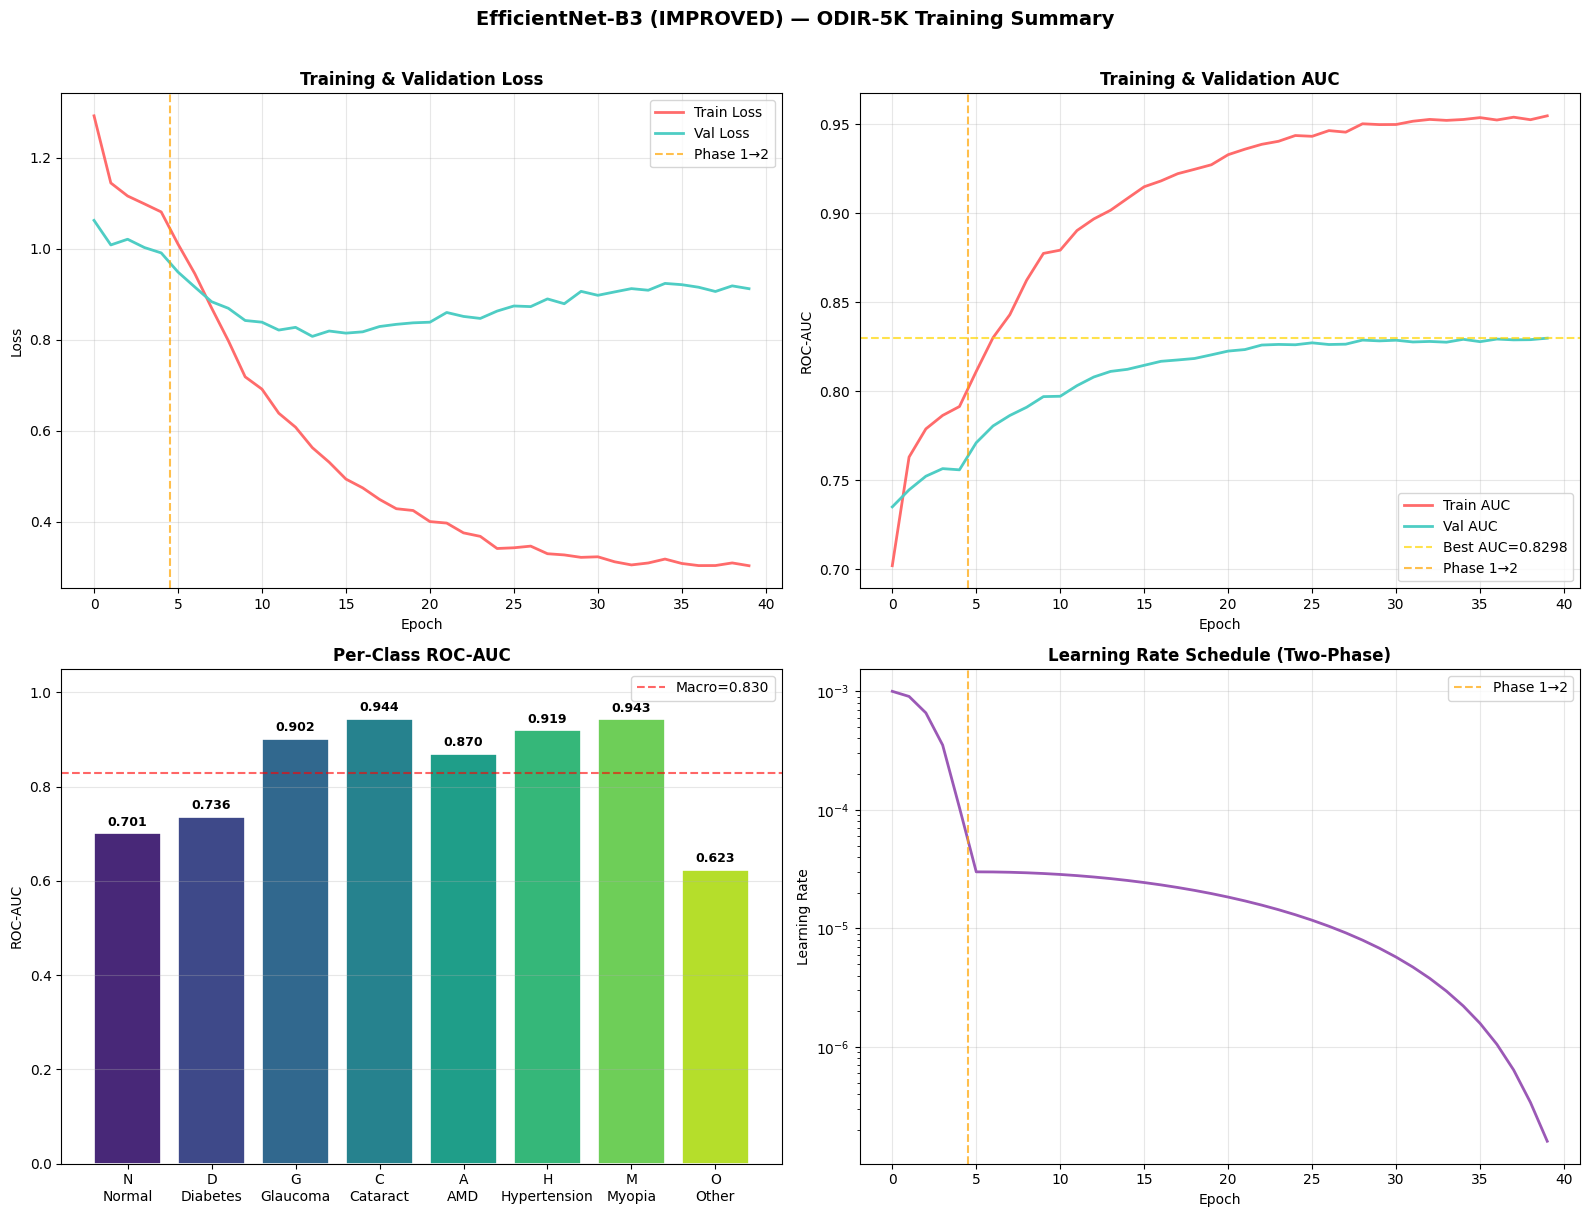

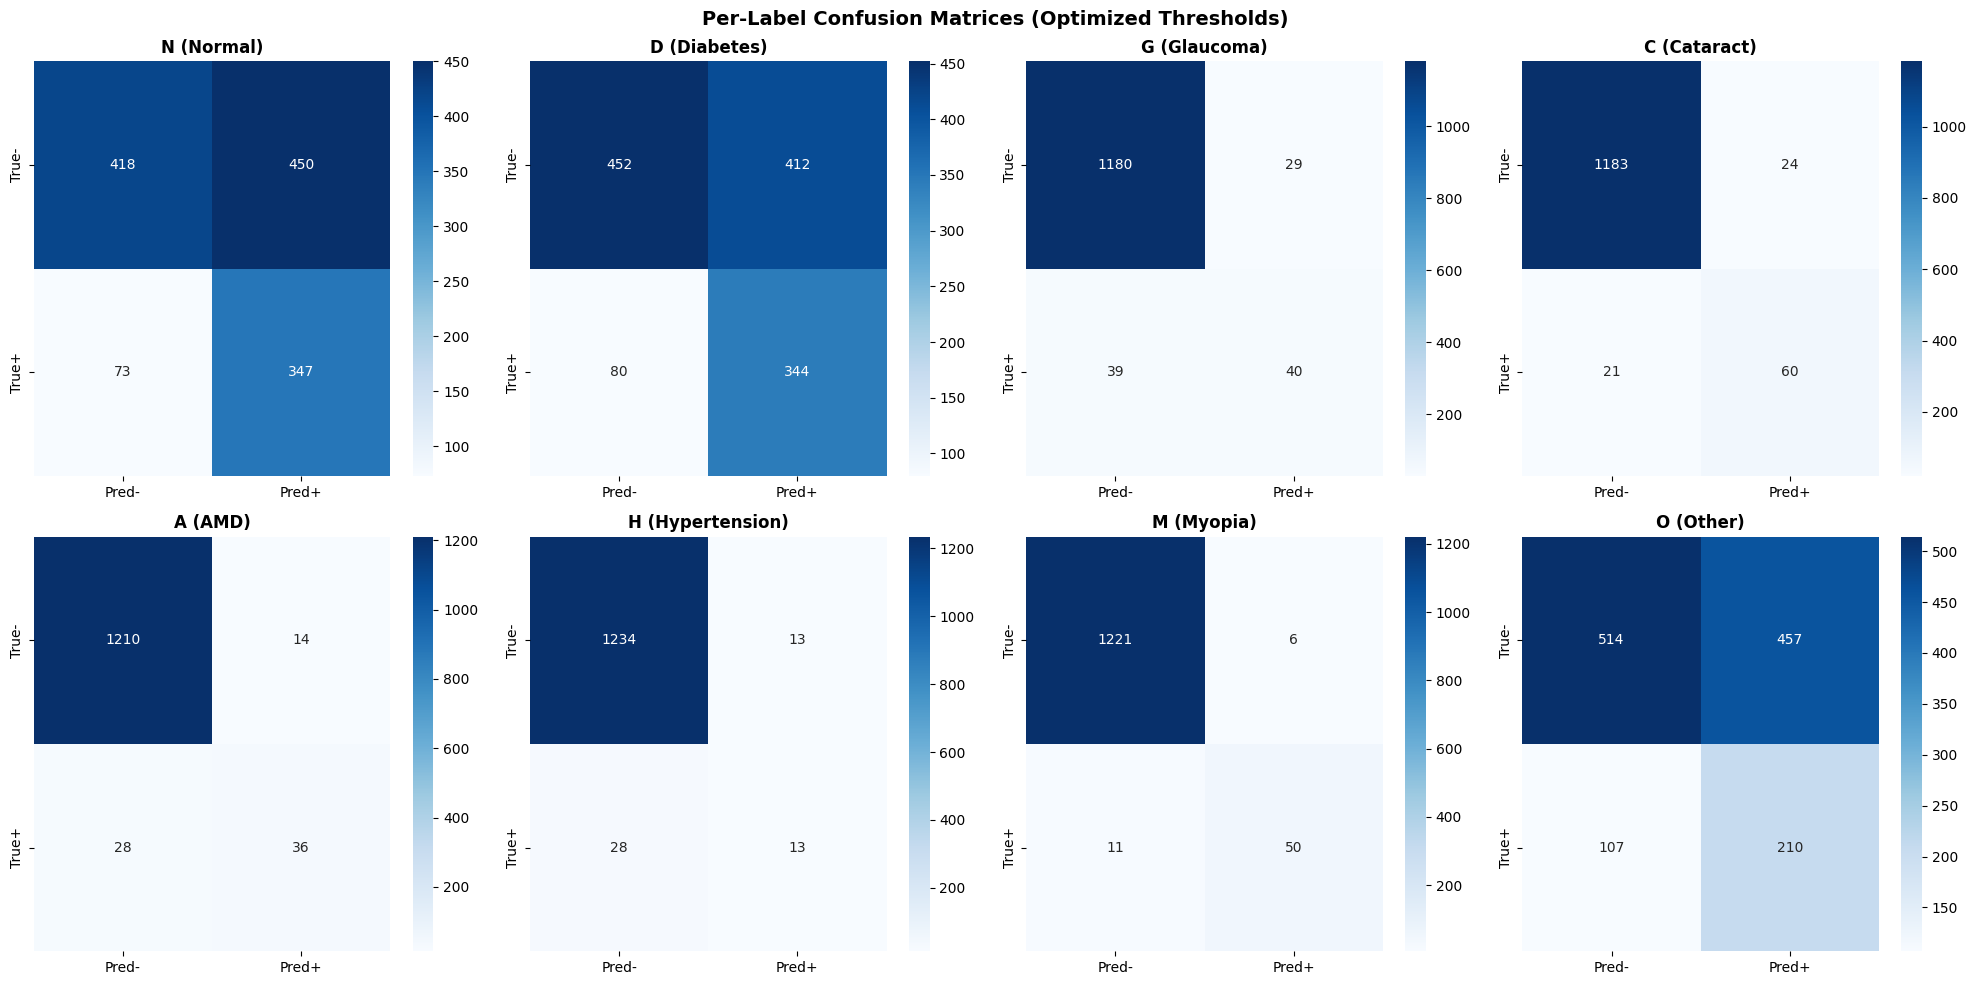

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 16a: Loss curves
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', linewidth=2, color='#FF6B6B')
ax.plot(history['val_loss'], label='Val Loss', linewidth=2, color='#4ECDC4')
# [IMPROVED] Mark phase boundary
ax.axvline(x=cfg.WARMUP_EPOCHS - 0.5, color='orange', linestyle='--', alpha=0.7, label='Phase 1→2')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 16b: AUC curves
ax = axes[0, 1]
ax.plot(history['train_auc'], label='Train AUC', linewidth=2, color='#FF6B6B')
ax.plot(history['val_auc'], label='Val AUC', linewidth=2, color='#4ECDC4')
ax.axhline(y=best_auc, color='gold', linestyle='--', alpha=0.7, label=f'Best AUC={best_auc:.4f}')
ax.axvline(x=cfg.WARMUP_EPOCHS - 0.5, color='orange', linestyle='--', alpha=0.7, label='Phase 1→2')
ax.set_xlabel('Epoch')
ax.set_ylabel('ROC-AUC')
ax.set_title('Training & Validation AUC', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 16c: Per-class AUC bar chart
ax = axes[1, 0]
class_names = [f"{c}\n{cfg.DISEASE_NAMES[c]}" for c in cfg.DISEASE_COLUMNS]
colors_bar = sns.color_palette("viridis", n_colors=cfg.NUM_CLASSES)
bars = ax.bar(class_names, auc_per_class, color=colors_bar, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, auc_per_class):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('ROC-AUC')
ax.set_title('Per-Class ROC-AUC', fontweight='bold')
ax.set_ylim(0, 1.05)
ax.axhline(y=auc_macro, color='red', linestyle='--', alpha=0.6, label=f'Macro={auc_macro:.3f}')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 16d: Learning rate schedule
ax = axes[1, 1]
ax.plot(history['lr'], linewidth=2, color='#9B59B6')
ax.axvline(x=cfg.WARMUP_EPOCHS - 0.5, color='orange', linestyle='--', alpha=0.7, label='Phase 1→2')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Schedule (Two-Phase)', fontweight='bold')
ax.set_yscale('log')
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle('EfficientNet-B3 (IMPROVED) — ODIR-5K Training Summary', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(cfg.REPORTS_DIR, "training_curves.png"), dpi=150, bbox_inches='tight')
plt.show()

# --- Confusion Matrices ---
cm = multilabel_confusion_matrix(y_true, y_pred_opt)
fig, axes_cm = plt.subplots(2, 4, figsize=(20, 10))
for i, (ax, col) in enumerate(zip(axes_cm.flatten(), cfg.DISEASE_COLUMNS)):
    sns.heatmap(cm[i], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred-', 'Pred+'], yticklabels=['True-', 'True+'])
    ax.set_title(f'{col} ({cfg.DISEASE_NAMES[col]})', fontweight='bold')

plt.suptitle('Per-Label Confusion Matrices (Optimized Thresholds)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(cfg.REPORTS_DIR, "confusion_matrices.png"), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print("=" * 70)
print("💾 FINAL MODEL SAVE")
print("=" * 70)

# Save full checkpoint
checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'config': {k: v for k, v in vars(cfg).items() if not k.startswith('_')},
    'best_auc': best_auc,
    'optimal_thresholds': optimal_thresholds,
    'metrics': metrics,
    'history': history,
    'disease_columns': cfg.DISEASE_COLUMNS,
    'training_phases': {
        'phase1_warmup_epochs': cfg.WARMUP_EPOCHS,
        'phase1_lr': cfg.WARMUP_LR,
        'phase2_finetune_epochs': phase2_epochs,
        'phase2_lr': cfg.LR,
    },
    'improvements': [
        'LR_3e-5', 'WeightedRandomSampler', 'TwoPhaseTraining',
        'CLAHE_preprocessing', 'StratifiedSplit', 'ExpandedThresholdSearch',
    ],
}
checkpoint_path = cfg.MODEL_PATH.replace('.pth', '_checkpoint.pth')
torch.save(checkpoint, checkpoint_path)

# Save weights only (lighter)
torch.save(model.state_dict(), cfg.MODEL_PATH)

print(f"   ✅ Weights:    {cfg.MODEL_PATH}")
print(f"   ✅ Checkpoint: {checkpoint_path}")
print(f"   ✅ Reports:    {cfg.REPORTS_DIR}/")
print(f"\n🎯 Best Validation AUC: {best_auc:.4f}")
print(f"   F1 Macro (opt thresh): {f1_mac:.4f}")
print(f"   F1 Micro (opt thresh): {f1_mic:.4f}")

# Summary of improvements applied
print(f"\n📋 Improvements Applied:")
print(f"   1. ✅ Learning rate: 1e-4 → 3e-5")
print(f"   2. ✅ WeightedRandomSampler for class imbalance")
print(f"   3. ✅ Two-phase training (head warmup + full fine-tuning)")
print(f"   4. ✅ CLAHE preprocessing (retinal image enhancement)")
print(f"   5. ✅ Approximate stratified split with imbalance logging")
print(f"   6. ✅ Expanded threshold search (0.05–0.95)")
print(f"   7. {'✅' if cfg.DENSENET_PRED_PATH else '⏳'} Ensemble with DenseNet121 {'(active)' if cfg.DENSENET_PRED_PATH else '(ready — set DENSENET_PRED_PATH)'}")

print("\n✅ Pipeline complete — ready for comparison with DenseNet121 baseline.")

💾 FINAL MODEL SAVE
   ✅ Weights:    ./efficientnet_odir_final.pth
   ✅ Checkpoint: ./efficientnet_odir_final_checkpoint.pth
   ✅ Reports:    ./reports_effnet/

🎯 Best Validation AUC: 0.8298
   F1 Macro (opt thresh): 0.5903
   F1 Micro (opt thresh): 0.5511

📋 Improvements Applied:
   1. ✅ Learning rate: 1e-4 → 3e-5
   2. ✅ WeightedRandomSampler for class imbalance
   3. ✅ Two-phase training (head warmup + full fine-tuning)
   4. ✅ CLAHE preprocessing (retinal image enhancement)
   5. ✅ Approximate stratified split with imbalance logging
   6. ✅ Expanded threshold search (0.05–0.95)
   7. ⏳ Ensemble with DenseNet121 (ready — set DENSENET_PRED_PATH)

✅ Pipeline complete — ready for comparison with DenseNet121 baseline.
